## Importing the Necessary Libraries and the Dataset

In [1]:
from __future__ import division

import warnings
from collections import namedtuple
import torch
import torch.nn as nn
from torch.jit.annotations import Optional, Tuple
from torch import Tensor
import os
import numpy as np
import os.path
from glob import glob
from PIL import Image
from tqdm import tqdm
import torchvision.datasets as dset
import torch.utils.data as data
from torchvision import transforms
from ipywidgets import IntProgress
import logging 
import matplotlib.pyplot as plt


## GPU Device Configuration

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else: 
    device = 'cpu'

## Setting Hyperparameters

In [3]:
learning_rate = 0.01 
batch_train_size = 20 
batch_test_size = 20 
num_epochs = 50

In [4]:
output_dir = "./outputs"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

## Image Processing 

In [5]:
train_transform = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ToTensor()]) 
test_transform = transforms.Compose([transforms.ToTensor()]) 

## Data Loading & Preparation

In [6]:
train_set = dset.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
train_loader = data.DataLoader(dataset=train_set, batch_size=batch_train_size, shuffle=True)
test_set = dset.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
test_loader = data.DataLoader(dataset=test_set, batch_size=batch_test_size, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


## Inception Module

In [7]:
class Inception(nn.Module):
    def __init__(self, in_planes, kernel_1_x, kernel_3_in, kernel_3_x, kernel_5_in, kernel_5_x, pool_planes):
        super(Inception, self).__init__()
        # 1x1 conv branch
        self.b1 = nn.Sequential(
            nn.Conv2d(in_planes, kernel_1_x, kernel_size=1),
            nn.BatchNorm2d(kernel_1_x),
            nn.ReLU(True),
        )

        # 1x1 conv -> 3x3 conv branch
        self.b2 = nn.Sequential(
            nn.Conv2d(in_planes, kernel_3_in, kernel_size = 1),
            nn.BatchNorm2d(kernel_3_in), 
            nn.ReLU(True), 
            nn.Conv2d(kernel_3_in, kernel_3_x, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(kernel_3_x), 
            nn.ReLU(True)
        )


        # 1x1 conv -> 5x5 conv branch
        self.b3 = nn.Sequential(
            nn.Conv2d(in_planes, kernel_5_in, kernel_size = 1),
            nn.BatchNorm2d(kernel_5_in), 
            nn.ReLU(True), 
            nn.Conv2d(kernel_5_in, kernel_5_x, kernel_size = 5, padding = 2),
            nn.BatchNorm2d(kernel_5_x), 
            nn.ReLU(True)
        )

        # 3x3 max pool -> 1x1 conv branch
        self.b4 = nn.Sequential(
            nn.MaxPool2d(kernel_size = 3, stride = 1, padding = 1),
            nn.Conv2d(in_planes, pool_planes, kernel_size = 1),
            nn.BatchNorm2d(pool_planes), 
            nn.ReLU(True)
        )
       

    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim = 1)
        

## GoogLeNet Module

In [8]:
class Conv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride = 1, padding = 0):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride = stride, padding = padding)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

In [9]:
class GoogleNet(nn.Module):
    def __init__(self, num_classes = 10):
        super(GoogleNet, self).__init__()
        
        self.conv1 = Conv(in_ch = 3, out_ch = 192, kernel_size = (3,3), padding = 1)
        
        self.inc1 = Inception(in_planes = 192,
                              kernel_1_x = 64,
                              kernel_3_in = 96,
                              kernel_3_x = 128, 
                              kernel_5_in = 16, 
                              kernel_5_x = 32, 
                              pool_planes = 32
                              )
        self.inc2 = Inception(in_planes = 256,
                              kernel_1_x = 128,
                              kernel_3_in = 128,
                              kernel_3_x = 192, 
                              kernel_5_in = 32, 
                              kernel_5_x = 96, 
                              pool_planes = 64
                              )
        
        self.maxpool1 = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)
        
        self.inc3 = Inception(in_planes = 480,
                              kernel_1_x = 192,
                              kernel_3_in = 96,
                              kernel_3_x = 208, 
                              kernel_5_in = 16, 
                              kernel_5_x = 48, 
                              pool_planes = 64
                              )

        self.inc4 = Inception(in_planes = 512,
                              kernel_1_x = 160,
                              kernel_3_in = 112,
                              kernel_3_x = 224, 
                              kernel_5_in = 24, 
                              kernel_5_x = 64, 
                              pool_planes = 64
                              )

        self.inc5 = Inception(in_planes = 512,
                              kernel_1_x = 128,
                              kernel_3_in = 128,
                              kernel_3_x = 256, 
                              kernel_5_in = 24, 
                              kernel_5_x = 64, 
                              pool_planes = 64
                              )

        self.inc6 = Inception(in_planes = 512,
                              kernel_1_x = 112,
                              kernel_3_in = 144,
                              kernel_3_x = 288, 
                              kernel_5_in = 32, 
                              kernel_5_x = 64, 
                              pool_planes = 64
                              )

        self.inc7 = Inception(in_planes = 528,
                              kernel_1_x = 256,
                              kernel_3_in = 160,
                              kernel_3_x = 320, 
                              kernel_5_in = 32, 
                              kernel_5_x = 128, 
                              pool_planes = 128
                              )


        self.maxpool2 = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

        self.inc8 = Inception(in_planes = 832,
                              kernel_1_x = 256,
                              kernel_3_in = 160,
                              kernel_3_x = 320, 
                              kernel_5_in = 32, 
                              kernel_5_x = 128, 
                              pool_planes = 128
                              )

        self.inc9 = Inception(in_planes = 832,
                              kernel_1_x = 384,
                              kernel_3_in = 192,
                              kernel_3_x = 384, 
                              kernel_5_in = 48, 
                              kernel_5_x = 128, 
                              pool_planes = 128
                              )

        self.avgpool = nn.AvgPool2d(kernel_size = 8, stride = 1)

        self.fc1 = nn.Linear(1024, num_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.inc1(x)
        x = self.inc2(x)
        x = self.maxpool1(x)
        x = self.inc3(x)
        x = self.inc4(x)
        x = self.inc5(x)
        x = self.inc6(x)
        x = self.inc7(x)
        x = self.maxpool2(x)
        x = self.inc8(x)
        x = self.inc9(x)
        x = self.avgpool(x)
        x = torch.flatten(x,1)
        x = self.fc1(x)
        return x
    

In [10]:
model = GoogleNet(num_classes=10).to(device)

In [11]:
# Criterion
criterion   = nn.CrossEntropyLoss()

# Optimizer
optimizer   = torch.optim.Adam(model.parameters(), lr = learning_rate)

# Scheduler
scheduler   = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [50, 100], gamma = 0.5)

## Training

In [12]:
def train():
    # Set our network to the training mode.
    model.train()
    
    # Initialize the train loss, total data size, and number corrected predictions.
    train_loss = 0.0
    data_size = 0
    correct_preds = 0
    
    # Put the data to the correct devices using .to()
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)
    
        # Reset the gradient of the optimzier.
        optimizer.zero_grad()
    
        # Feed the data forward to the Google Net
        outputs = model(images)
    
        # Use the criterion function to compute the loss term
        loss = criterion(outputs, labels)
    
        # Backpropagate the loss
        loss.backward()
    
        # Update the network parameters using the optimizier
        optimizer.step()
    
        # Accumulate the training loss
        train_loss += loss.item() * images.size(0)
    
        # Find the prediction
        _, preds = outputs.max(dim = 1)
        data_size += labels.size(0)
        correct_preds += preds.eq(labels).sum().item()
    
        # Print average loss and accuracy every 100 epochs
        if batch_idx % 100 == 0:
            avg_loss = train_loss / data_size
            acc = correct_preds / data_size
            print(f"[Batch {batch_idx:4d}]  Loss: {avg_loss:.4f}  Acc: {acc:.4f}")
        
    
    epoch_loss = train_loss / data_size
    epoch_acc  = correct_preds / data_size
    print(f"Epoch Training →  Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")




In [13]:
def train():
    # Set our network to the training mode.
    model.train()
    
    # Initialize the train loss, total data size, and number corrected predictions.
    train_loss = 0.0
    data_size = 0
    correct_preds = 0
    
    # Put the data to the correct devices using .to()
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)
    
        # Reset the gradient of the optimzier.
        optimizer.zero_grad()
    
        # Feed the data forward to the Google Net
        outputs = model(images)
    
        # Use the criterion function to compute the loss term
        loss = criterion(outputs, labels)
    
        # Backpropagate the loss
        loss.backward()
    
        # Update the network parameters using the optimizier
        optimizer.step()
    
        # Accumulate the training loss
        train_loss += loss.item() * images.size(0)

        # Find the prediction
        _, preds = outputs.max(dim = 1)
        data_size += labels.size(0)
        correct_preds += preds.eq(labels).sum().item()
    
        # Print average loss and accuracy every 100 epochs
        if batch_idx % 100 == 0:
            avg_loss = train_loss / data_size
            acc = correct_preds / data_size
            print(f"[Train Batch {batch_idx:4d}]  Loss: {avg_loss:.4f}  Acc: {acc:.4f}")
        
    
    epoch_loss = train_loss / data_size
    epoch_acc  = correct_preds / data_size
    
    return epoch_loss, epoch_acc

## Testing

In [14]:
def test():
    # Set our network to the testing (evaluation) mode.
    model.eval()
    
    # Initialize the train loss, total data size, and number corrected predictions.
    test_loss = 0.0
    data_size = 0
    correct_preds = 0
    
    # For each data in the testing split, we warp it using torch.no_grad()
    with torch.no_grad():
        # Put the data to the correct devices using .to()
        for batch_idx, (images, labels) in enumerate(test_loader):
            # Move data to GPU
            images = images.to(device)
            labels = labels.to(device)
        
            # Feed the data forward to the Google Net
            outputs = model(images)
        
            # Use the criterion function to compute the loss term
            loss = criterion(outputs, labels)
        
            # Accumulate the testing loss
            test_loss += loss.item() * images.size(0)
        
            # Find the prediction. hint: using torch.max()
            _, preds = outputs.max(dim = 1)
            data_size += labels.size(0)
            correct_preds += preds.eq(labels).sum().item()
        
            # Print average loss and accuracy every 100 epochs
            if batch_idx % 100 == 0:
                avg_loss = test_loss / data_size
                acc = correct_preds / data_size
                print(f"[Test Batch {batch_idx:4d}]  Loss: {avg_loss:.4f}  Acc: {acc:.4f}")
        
    
    epoch_loss = test_loss / data_size
    epoch_acc  = correct_preds / data_size

    return epoch_loss, epoch_acc

## Epoch

In [17]:
train_acc_history = []
test_acc_history  = []
train_loss_history = []
test_loss_history = []

for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")
    train_loss, train_acc = train()
    scheduler.step()
    test_loss,  test_acc  = test()
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(f"→ Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")

    torch.save(
        model.state_dict(),
        f"{output_dir}/googlenet_epoch{epoch:03d}.pth"
    )



Epoch 1/50
[Train Batch    0]  Loss: 0.0005  Acc: 1.0000
[Train Batch  100]  Loss: 0.0396  Acc: 0.9876
[Train Batch  200]  Loss: 0.0338  Acc: 0.9886
[Train Batch  300]  Loss: 0.0317  Acc: 0.9890
[Train Batch  400]  Loss: 0.0306  Acc: 0.9892
[Train Batch  500]  Loss: 0.0293  Acc: 0.9898
[Train Batch  600]  Loss: 0.0276  Acc: 0.9903
[Train Batch  700]  Loss: 0.0268  Acc: 0.9910
[Train Batch  800]  Loss: 0.0268  Acc: 0.9913
[Train Batch  900]  Loss: 0.0264  Acc: 0.9913
[Train Batch 1000]  Loss: 0.0265  Acc: 0.9914
[Train Batch 1100]  Loss: 0.0255  Acc: 0.9916
[Train Batch 1200]  Loss: 0.0249  Acc: 0.9919
[Train Batch 1300]  Loss: 0.0250  Acc: 0.9917
[Train Batch 1400]  Loss: 0.0248  Acc: 0.9918
[Train Batch 1500]  Loss: 0.0247  Acc: 0.9918
[Train Batch 1600]  Loss: 0.0245  Acc: 0.9920
[Train Batch 1700]  Loss: 0.0246  Acc: 0.9919
[Train Batch 1800]  Loss: 0.0246  Acc: 0.9917
[Train Batch 1900]  Loss: 0.0244  Acc: 0.9917
[Train Batch 2000]  Loss: 0.0245  Acc: 0.9919
[Train Batch 2100]  Lo

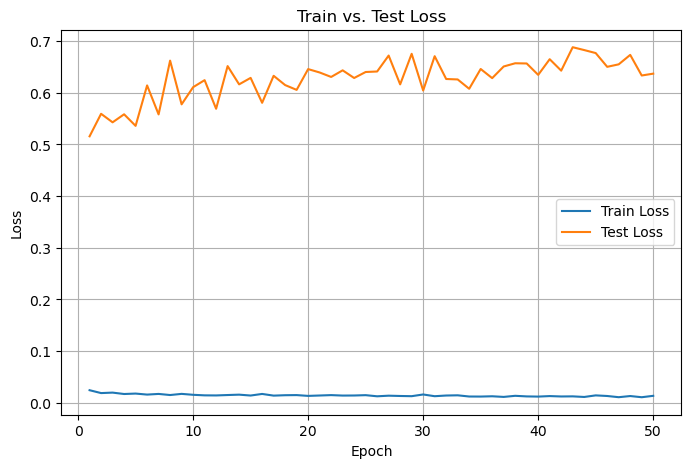

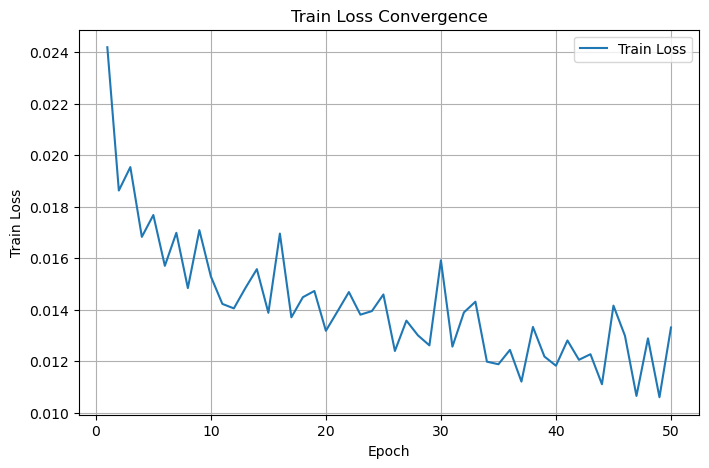

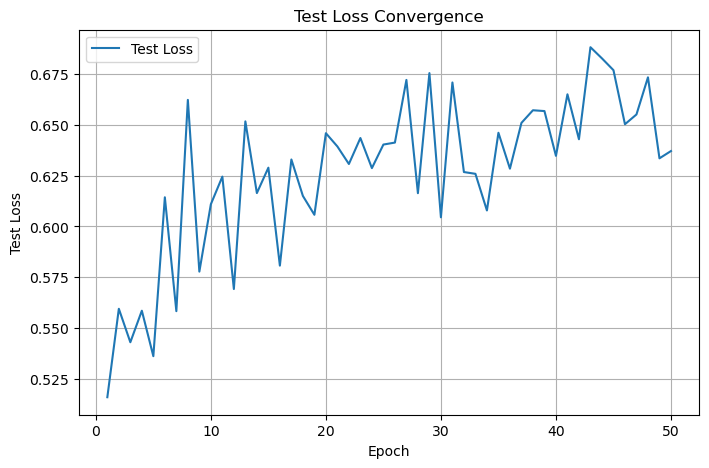

In [19]:
epochs = range(1, num_epochs + 1)

# Combined plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss_history, label="Train Loss")
plt.plot(epochs, test_loss_history,  label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs. Test Loss")
plt.legend()
plt.grid(True)
plt.show()

# Train loss only
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss_history, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Train Loss Convergence")
plt.legend()
plt.grid(True)
plt.show()

# Test loss only
plt.figure(figsize=(8,5))
plt.plot(epochs, test_loss_history, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss Convergence")
plt.legend()
plt.grid(True)
plt.show()